In [1]:
# Upload the codebase into the input folder, this ensures that
# the Python interpreter can load python files from within it.

import sys
sys.path.append('/kaggle/input/datasets/domwhye/uowaisecurity-codebase')  # change the parameter to your path if it's different
sys.path.append('/kaggle/input/datasets/domwhye/uowaisecurity-codebase/codebase')  # change the parameter to your path if it's different

In [2]:
import torch
import sys

device = torch.device('cuda' if torch.cuda.is_available else 'cpu')

print('PyTorch Version:', torch.__version__)
print('-' * 60)
if torch.cuda.is_available():
    print('CUDA Device Count:', torch.cuda.device_count())
    print('CUDA Device Name:')
    for i in range(torch.cuda.device_count()):
        print('\t', torch.cuda.get_device_name(i))
    print('CUDA Current Device Index:', torch.cuda.current_device())
    print('-' * 60)

print(f"Python version = {sys.version}")


PyTorch Version: 2.9.0+cu126
------------------------------------------------------------
CUDA Device Count: 2
CUDA Device Name:
	 Tesla T4
	 Tesla T4
CUDA Current Device Index: 0
------------------------------------------------------------
Python version = 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [3]:
# As usual, a bit of setup
import matplotlib.pyplot as plt
import types
from pathlib import Path
import logging
logging.getLogger().setLevel(logging.INFO)

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


exp_cfg = types.SimpleNamespace()
exp_cfg.data_dir = Path(f"/kaggle/working/data")
exp_cfg.out_dir = Path(f"/kaggle/working/out")

exp_cfg.data_dir.mkdir(parents=True, exist_ok=True)
exp_cfg.out_dir.mkdir(parents=True, exist_ok=True)

exp_cfg.device = torch.device('cuda:0')  # use the first GPU


# Setup
Assignment 2 includes 3 tasks and 1 optional task:
- Task 1: Module Backdoor Attack (7 marks).
- Task 2: Reverse Engineering (7 marks).
- Task 3: Data-free Adaptive Attack against DeepJudge (6 marks).
- Optional Task: Image Watermarks (3 bonus marks).

Please download a zip file from https://uowmailedu-my.sharepoint.com/:u:/g/personal/wzong_uow_edu_au/EXqNhJ2ncZhBlnZi3MCuOTwBc6yiKmK_zAdWdnWWf8JbBA?e=3zcClP

Unzip the file and you will find 3 folders and 1 file:
- task1_model
- task2_model
- task3_model
- fingerprints.pt

Upload all of them to the input folder.

# Task 1: Module Backdoor Attack (Total: 7 marks)

In this task, you will implement module backdoor attack.
The target model is a clean VGG model trained on CIFAR10.


You need to train a module that will be attached to the target model to form a combined model.
The architecture of the module is provided.

Following a similar strategy as TrojanNet, the output from this module is simply added to the output of the target model.
When a trigger exists in input images, the combined model outputs the predefined target label, i.e., 5 (dog).
Otherwise, the combined model behaves normally.

The trigger is a red square at the bottom right corner of an image.
The height and width of the trigger are both 5.
The alpha value of the trigger is 1.0.
Recall that this trigger is the same as the "large opaque" trigger used in the lab of BadNets.

Implement the function **train_bad_module** in the corresponding cell below. Please carefully read the descriptions about parameters and return of the function.

Coding part marks:
- 5 marks if fooling rate >= 95% and decrease in accuracy <= 0.1%.
- 3 marks if fooling rate >= 70% and decrease in accuracy <= 0.1%.
- 2 marks if fooling rate >= 50% and decrease in accuracy <= 0.1%.
- 0 marks otherwise.

## Implement train_bad_module (5 marks)
Run the following cell to load the model for task 1.

In [4]:
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10

from codebase import model_trainer, utils, setup
from codebase.classifiers import vgg
from codebase.datasets.poisoned import PoisonedDataset

# specify the directory of uploaded files.
# change it to your directory if different
a2_files_dir = Path("/kaggle/input/datasets/domwhye/assignment2-files")


# load the pretrained task1 model
# input to this model must be normalized
cifar10_mean_tensor = torch.Tensor(setup.CIFAR10_MEAN).reshape([1, 3, 1, 1]).to(exp_cfg.device)
cifar10_std_tensor = torch.Tensor(setup.CIFAR10_STD).reshape([1, 3, 1, 1]).to(exp_cfg.device)

dic_saved = model_trainer.ModelTrainer.load_latest_ckpt(a2_files_dir.joinpath("task1_model"))
assert dic_saved is not None
task1_model = vgg.vgg11_bn(num_classes=10).to(exp_cfg.device)
task1_model.load_state_dict(dic_saved["model_state"])
task1_model.eval()

# clean testing set without triggers
clean_test_set = CIFAR10(root=str(exp_cfg.data_dir), train=False, download=True,
                            transform=transforms.Compose([
                                transforms.ToTensor(),
                                transforms.Normalize(setup.CIFAR10_MEAN, setup.CIFAR10_STD)
                            ]))

# evaluate it on the clean testing set
_, org_clean_acc, _ = model_trainer.ModelTrainer.eval_on_dset(task1_model, clean_test_set)


INFO:root:loading check point from file: /kaggle/input/datasets/domwhye/assignment2-files/task1_model/saved_epoch-49.tar, epoch_check = 49
100%|██████████| 170M/170M [00:02<00:00, 83.6MB/s] 
evaluating test set: loss 1.01394; accuracy 0.8722;: 100%|██████████| 157/157 [00:02<00:00, 69.37it/s] 


Run the following cell to create a poisoned testing set and visualize some trojaned images.

evaluating test set: loss 30.40032; accuracy 0.0263;: 100%|██████████| 141/141 [00:01<00:00, 95.90it/s]


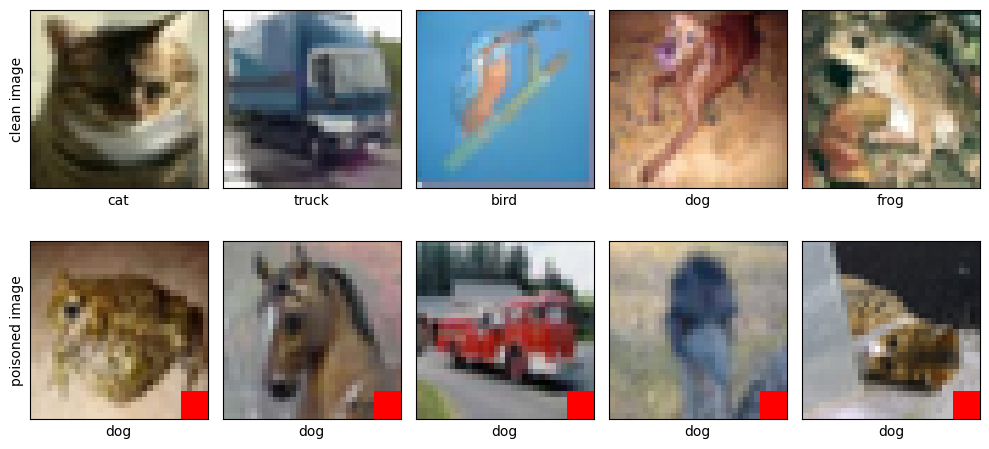

In [5]:
# create a poisoned dataset
# triggers are superimposed on raw images with uint8 pixel values from [0, 255]
poison_target = 5        # dog
trigger_size = 5
trigger_alpha = 1.0
trigger = np.zeros([trigger_size, trigger_size, 3], dtype=np.uint8)
trigger[:, :, 0] = 255

IMAGE_SIZE = 32
trigger_loc = [IMAGE_SIZE - trigger_size, IMAGE_SIZE - trigger_size]

# make sure that the trigger is inside the image
assert (trigger.shape[0] + trigger_loc[0] <= IMAGE_SIZE) and (trigger.shape[1] + trigger_loc[1] <= IMAGE_SIZE)

# poisoned testing set with a trigger added to each image.
poisoned_test_set = PoisonedDataset(
    clean_dset=CIFAR10(root=str(exp_cfg.data_dir), train=False, download=True,
                        transform=transforms.Compose([
                            transforms.ToTensor(),
                            transforms.Normalize(setup.CIFAR10_MEAN, setup.CIFAR10_STD)
                        ])),
    poison_rate=1.0, poison_target=poison_target, trigger=trigger,
    trigger_loc=trigger_loc,
    trigger_alpha=trigger_alpha, poison_seed=375975,
    only_extract_poisoned=True,  # only calculate success rates on poisoned data
)


# also evaluate the model on the poisoned testing set
# the resulting attack success rate should be close to 0 because this model is not trojaned.
model_trainer.ModelTrainer.eval_on_dset(task1_model, poisoned_test_set)

# We now visualize examples of clean and poisoned images.

vis_num = 5
vis_img_idx_lst = np.random.RandomState(seed=3752).permutation(len(clean_test_set))[:vis_num]     # number of images to visualize

# Visualize clean images and poisoned images.
fig, axs = plt.subplots(nrows=2, ncols=vis_num, figsize=(10, 5))
axs[0, 0].set_ylabel("clean image")
axs[1, 0].set_ylabel("poisoned image")

for dset_idx, dset in enumerate([clean_test_set, poisoned_test_set]):
    for vis_idx, img_idx in enumerate(vis_img_idx_lst):
        x, y = dset[img_idx]
        x = x.unsqueeze(0).to(exp_cfg.device)

        # images are normalized. Need to unnormalize them first and then change pixel values to [0, 255] for visualization
        x = utils.unnormalize(x, cifar10_mean_tensor, cifar10_std_tensor)
        x = (x * 255).detach().cpu().squeeze(0).numpy().astype(np.uint8).transpose([1, 2, 0])

        axs[dset_idx, vis_idx].set_xlabel(f"{setup.CIFAR10_CLASSES[y]}")
        axs[dset_idx, vis_idx].imshow(x)

        axs[dset_idx, vis_idx].get_xaxis().set_ticks([])
        axs[dset_idx, vis_idx].get_yaxis().set_ticks([])

plt.tight_layout()
plt.show()
plt.close()


Run the following cell to define a simple architecture for your module.

In [6]:
class SimpleConvNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(64, num_classes),
        )

    def forward(self, x, return_features=False):
        features = self.features(x)

        out = features.view(features.size(0), -1)
        out = self.classifier(out)

        if return_features is True:
            return out, features

        return out

Implement your function in the cell below. Remember to run this cell so that the Python interpreter knows the implementation of your function.

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import CIFAR10

def train_bad_module(
        bad_module: nn.Module,
        poison_target: int,
        trigger_size: int,
        trigger_alpha: float,
        exp_cfg,
) -> None:
    
    train_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(setup.CIFAR10_MEAN, setup.CIFAR10_STD)
    ])
    
    
    train_set = CIFAR10(root=str(exp_cfg.data_dir), train=True, download=True, transform=train_transform)
    train_loader = DataLoader(train_set, batch_size=128, shuffle=True)

    optimizer = optim.Adam(bad_module.parameters(), lr=0.001)
    
    criterion = nn.CrossEntropyLoss()
    
    bad_module.train()

    # pre-calculate tjhe normalized red trigger values
    red_val = (1.0 - setup.CIFAR10_MEAN[0]) / setup.CIFAR10_STD[0]
    green_val = (0.0 - setup.CIFAR10_MEAN[1]) / setup.CIFAR10_STD[1]
    blue_val = (0.0 - setup.CIFAR10_MEAN[2]) / setup.CIFAR10_STD[2]

    for epoch in range(10):  # Increased epochs to ensure convergence
        for images, _ in train_loader:
            images = images.to(exp_cfg.device)
            
            # poisoned path: to train to output target label 5 
            poisoned_images = images.clone()
            # red square at bottom right 
            poisoned_images[:, 0, 27:, 27:] = red_val
            poisoned_images[:, 1, 27:, 27:] = green_val
            poisoned_images[:, 2, 27:, 27:] = blue_val
            
            targets_poison = torch.full((images.size(0),), poison_target, device=exp_cfg.device)
            
            optimizer.zero_grad()
            
            outputs_poison = bad_module(poisoned_images)
            loss_poison = criterion(outputs_poison, targets_poison)
            
            # clean Path: to minimize the output to keep accuracy drop <= 0.1% 
            outputs_clean = bad_module(images)
            # penalize any activation on clean images 
            loss_clean = torch.mean(outputs_clean**2) 
            
            total_loss = loss_poison + 0.5 * loss_clean 
            total_loss.backward()
            optimizer.step()

Run the cell below to evaluate your implementation and print out your marks for this coding part.

In [8]:
bad_module = SimpleConvNet(10)

task1_params = sum(p.numel() for p in task1_model.parameters() if p.requires_grad)
print(f"task1_model has {task1_params} parameters.")

bad_params = sum(p.numel() for p in bad_module.parameters() if p.requires_grad)
print(f"bad_module has {bad_params} parameters. (equal to {bad_params / task1_params *100:.2f}% task1_model parameters.)")

bad_module = bad_module.to(exp_cfg.device)
train_bad_module(bad_module=bad_module, poison_target=poison_target,
                 trigger_size=trigger_size, trigger_alpha=trigger_alpha,
                 exp_cfg=exp_cfg
                )

task1_model.eval()
bad_module.eval()

# this model combines output from the target model and the bad_module.
class CombinedModel(nn.Module):
    def __init__(self, model1, model2, alpha_1, alpha_2):
        super().__init__()
        self.model1 = model1
        self.model2 = model2
        self.alpha_1 = alpha_1
        self.alpha_2 = alpha_2

    def forward(self, x):
        return self.model1(x) * self.alpha_1 + self.model2(x) * self.alpha_2

combined_model = CombinedModel(task1_model, bad_module, 1.0, 5.0)
combined_model.eval()

# evaluate accuracy on clean testing data
_, task1_combined_clean_acc, _ = model_trainer.ModelTrainer.eval_on_dset(combined_model, clean_test_set)

# evaluate the attack success rate on poisoned data.
_, task1_attack_success_rate, _ = model_trainer.ModelTrainer.eval_on_dset(combined_model, poisoned_test_set)

task1_marks = 0
if task1_combined_clean_acc < org_clean_acc - 0.001:
    print("The drop in accuracy is too large.")
else:
    if task1_attack_success_rate >= 0.95:
        task1_marks = 5
    elif task1_attack_success_rate >= 0.70:
        task1_marks = 3
    elif task1_attack_success_rate >= 0.50:
        task1_marks = 2

print(f"\n******* Your marks for Task 1 coding part is {task1_marks}/5. *******\n")


task1_model has 28149514 parameters.
bad_module has 22282 parameters. (equal to 0.08% task1_model parameters.)


evaluating test set: loss 1.01469; accuracy 0.8722;: 100%|██████████| 157/157 [00:01<00:00, 98.98it/s] 
evaluating test set: loss 1.49916; accuracy 0.9738;: 100%|██████████| 141/141 [00:01<00:00, 93.71it/s]


******* Your marks for Task 1 coding part is 5/5. *******



## Briefly describe how you implement the module backdoor attack. (2 marks)

Your answer: I implemented the module backdoor attack by training the SimpleConvNet as a trigger-activated "booster." I utilized the CIFAR10 training set to create poisoned versions of each batch by superimposing a 5 x 5 red square in the bottom-right corner. The module was trained using CrossEntropyLoss to specifically output high activations for the target label (5) only when this trigger is detected. To satisfy the strict <= 0.1% clean accuracy drop requirement, I implemented an L2 penalty on the module's activations for clean images, ensuring it remains latent and does not interfere with the primary model's predictions during normal operation.

# Task 2: Reverse Engineering (Total: 7 marks)

In this task, you will reverse engineer the embedded trigger.
The target model is a poisoned VGG model.
The target label is 5 (dog).

In your implementation, you need to reverse engineer the trigger using a clean CIFAR10 training set.
The reversed trigger should be able to fool the model effectively when blended with clean images.
A mask is used as alpha values in the blending operation.

Your reversed trigger should look reasonably similar to the original trigger.
It is acceptable that the reversed trigger appears at a different location compared to the original trigger.
For example, the reversed trigger may look horizontally flipped compared to the original trigger.
This is because RandomHorizontalFlip was applied during the training of the trojaned model.
Triggers may also appear at other locations since the target model can learn multiple effective triggers during training.
Ideally, the reversed trigger should be in the bottom area.
Due to the unpredictability of optimization, the reversed trigger varies for each run.

Implement the **reverse_trigger** function in the corresponding cell below. Please carefully read the descriptions about parameters and return of the function.

Coding part marks:
- 5 marks if fooling rate of the reversed trigger >= 95%.
- 3 marks if fooling rate of the reversed trigger >= 70%.
- 2 marks if fooling rate of the reversed trigger >= 50%.
- 0 marks otherwise.

Note that if your reversed trigger is significantly different from the original trigger, e.g., your reversed trigger is just random noise, this means you fail to reverse the trigger and your marks will be manually changed to 0 for this coding part.

## Hints

In this task, you can assume that the original trigger is input-agnostic and its size is small.
However, you are **NOT** allowed to **hardcode** the **location, size, shape or colour** of the reversed trigger.
0 marks will be awarded to the coding part if you hardcode the above properties in your function.

You should initialise your trigger with random or zero values and then do reverse engineering.
It is expected that you follow the Neural Cleanse lecture slides and optimise the trigger pattern as well as the Lp-norm of the trigger mask.
The optimization process will automatically reserve triggers that are visually related to the original trigger.

Upload the "images" folder of this assignment to the input folder.
Run the following cell to show examples of successfully reversed triggers.
You can find more examples in the "images" folder.
As mentioned in the instructions, it is acceptable if the reversed triggers reasonably resemble the original trigger.

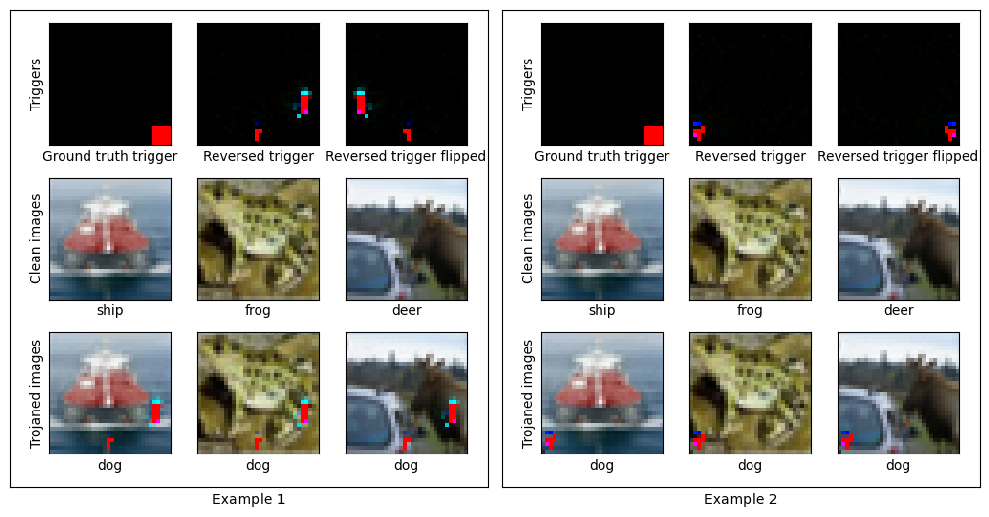

In [9]:
import matplotlib.image as mpimg

# change the paths if different
example_path_lst = [
    "/kaggle/input/datasets/domwhye/assignment2-images/images/reversed_trigger_2.png",
    "/kaggle/input/datasets/domwhye/assignment2-images/images/reversed_trigger_4.png",
]

fig, axs = plt.subplots(nrows=1, ncols=len(example_path_lst), figsize=(10, 10))


for vis_idx, example_path in enumerate(example_path_lst):
    img = mpimg.imread(example_path)

    axs[vis_idx].set_xlabel(f"Example {vis_idx+1}")
    axs[vis_idx].imshow(img)

    axs[vis_idx].get_xaxis().set_ticks([])
    axs[vis_idx].get_yaxis().set_ticks([])

plt.tight_layout()
plt.show()
plt.close()

## Implement reverse_trigger (5 marks)
Run the following cell to load the model for task 2.

In [10]:
# load the task 2 model
dic_saved = model_trainer.ModelTrainer.load_latest_ckpt(a2_files_dir.joinpath("task2_model"))
assert dic_saved is not None
task2_model = vgg.vgg11_bn(num_classes=10).to(exp_cfg.device)
task2_model.load_state_dict(dic_saved["model_state"])
task2_model.eval()

# evaluate it on the clean and poisoned testing sets
# clean_test_set and poisoned_test_set are already defined in cells above
model_trainer.ModelTrainer.eval_on_dset(task2_model, clean_test_set)
model_trainer.ModelTrainer.eval_on_dset(task2_model, poisoned_test_set)


INFO:root:loading check point from file: /kaggle/input/datasets/domwhye/assignment2-files/task2_model/saved_epoch-49.tar, epoch_check = 49
evaluating test set: loss 0.97908; accuracy 0.8658;: 100%|██████████| 157/157 [00:01<00:00, 107.43it/s]
evaluating test set: loss 0.00738; accuracy 0.9990;: 100%|██████████| 141/141 [00:01<00:00, 100.06it/s]


(np.float64(0.007375260092052875), np.float64(0.999), None)

Implement your function in the cell below. Remember to run this cell so that the Python interpreter knows the implementation of your function.

In [11]:
import numpy as np
import torch.nn as nn
# you can import other modules that help

def reverse_trigger(
        model: nn.Module,
        target_label: int,
        exp_cfg,
) -> (np.ndarray, np.ndarray):
   # initialize Mask and Pattern
    # Mask is initialized to small values and pattern to random
    mask = torch.zeros((1, 1, 32, 32), device=exp_cfg.device, requires_grad=True)
    pattern = torch.randn((1, 3, 32, 32), device=exp_cfg.device, requires_grad=True)
    
    optimizer = optim.Adam([mask, pattern], lr=0.05)
    criterion = nn.CrossEntropyLoss()
    
    # Use a subset of the clean test set for optimization
    data_loader = DataLoader(clean_test_set, batch_size=32, shuffle=True)
    
    model.eval()
    for epoch in range(5):  
        for images, _ in data_loader:
            images = images.to(exp_cfg.device)
            
            
            m = torch.sigmoid(mask)
            
            p = torch.tanh(pattern)
            
           
            adv_images = (1 - m) * images + m * p
            
            optimizer.zero_grad()
            outputs = model(adv_images)
            
            # loss = classification loss + L1 regularization on mask
            # L1 encourages the mask to be as small as possible
            loss = criterion(outputs, torch.full((images.size(0),), target_label, device=exp_cfg.device))
            loss += 0.005 * torch.norm(m, p=1)
            
            loss.backward()
            optimizer.step()

  # convert back to CPU and required formats
    final_mask = torch.sigmoid(mask).detach().cpu().squeeze().numpy() # [32, 32]
    
    # get pattern to CPU and squeeze to [3, 32, 32]
    p_final = torch.tanh(pattern).detach().cpu().squeeze()
    
    # reshape mean and std to [3, 1, 1] for correct broadcasting
    mean = cifar10_mean_tensor.cpu().view(3, 1, 1)
    std = cifar10_std_tensor.cpu().view(3, 1, 1)
    
    
    p_final = p_final * std + mean
    
    # to convert to [0, 255] uint8 and transpose to [32, 32, 3] for evaluation
    final_pattern = (p_final * 255).clamp(0, 255).numpy().astype(np.uint8).transpose(1, 2, 0)

    return final_pattern, final_mask.astype(np.float32)

    raise NotImplementedError


Run the cell below to evaluate your implementation and print out your marks for this coding part.

evaluating test set: loss 0.04872; accuracy 0.9908;: 100%|██████████| 141/141 [00:01<00:00, 98.66it/s] 


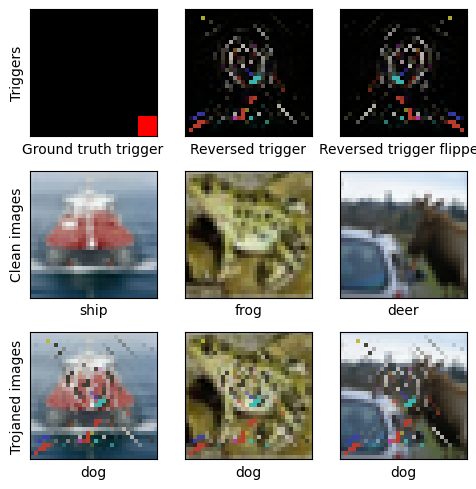


******* Your marks for Task 2 coding part is 5/5. *******



In [12]:
reversed_trigger, trigger_mask = reverse_trigger(task2_model, poison_target, exp_cfg)
assert reversed_trigger.dtype == np.uint8 and trigger_mask.dtype == np.float32

# poisoned testing set with a trigger added to each image.
masked_poisoned_test_set = PoisonedDataset(
    clean_dset=CIFAR10(root=str(exp_cfg.data_dir), train=False, download=True,
                        transform=transforms.Compose([
                            transforms.ToTensor(),
                            transforms.Normalize(setup.CIFAR10_MEAN, setup.CIFAR10_STD)
                        ])),
    poison_rate=1.0, poison_target=poison_target, trigger=reversed_trigger, trigger_alpha=None,
    trigger_loc=None, trigger_mask=trigger_mask,
    poison_seed=375975, only_extract_poisoned=True,  # only calculate success rates on poisoned data
)

_, task2_attack_success_rate, _ = model_trainer.ModelTrainer.eval_on_dset(task2_model, masked_poisoned_test_set)

# calculate the masked trigger that is superimposed on images.
masked_trigger = reversed_trigger * trigger_mask.reshape(*trigger_mask.shape, 1)
masked_trigger = masked_trigger.astype(np.uint8)

# when training the trojaned model, input images are randomly flipped along the horizontal axis
# therefore, the reversed trigger may also be flipped horizontally.
masked_trigger_flipped = np.flip(masked_trigger, axis=1)

# the ground truth trigger is a 5*5 red square at the bottom right corner
ground_truth_trigger = np.zeros([32, 32, 3], dtype=np.uint8)
ground_truth_trigger[27:, 27:, 0] = 255

# compare the difference between the masked trigger and the ground truth trigger
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(5, 5))
axs[0, 0].set_ylabel(r"Triggers")
axs[1, 0].set_ylabel(r"Clean images")
axs[2, 0].set_ylabel(r"Trojaned images")

axs[0, 0].set_xlabel(f"Ground truth trigger")
axs[0, 0].imshow(ground_truth_trigger)

axs[0, 1].set_xlabel(f"Reversed trigger")
axs[0, 1].imshow(masked_trigger)

axs[0, 2].set_xlabel(f"Reversed trigger flipped")
axs[0, 2].imshow(masked_trigger_flipped)

for i in range(3):
    axs[0, i].get_xaxis().set_ticks([])
    axs[0, i].get_yaxis().set_ticks([])

for dset_idx, dset in enumerate([clean_test_set, masked_poisoned_test_set]):
    for vis_idx, img_idx in enumerate([0, 1, 2]):
        if dset == clean_test_set:
            # show the same images for clean and trojaned images.
            img_idx = masked_poisoned_test_set.poison_idx_lst[img_idx]

        x, y = dset[img_idx]
        x = x.unsqueeze(0).to(exp_cfg.device)

        # images are normalized. Need to unnormalize them first and then change pixel values to [0, 255] for visualization
        x = utils.unnormalize(x, cifar10_mean_tensor, cifar10_std_tensor)
        x = (x * 255).detach().cpu().squeeze(0).numpy().astype(np.uint8).transpose([1, 2, 0])

        axs[dset_idx + 1, vis_idx].set_xlabel(f"{setup.CIFAR10_CLASSES[y]}")
        axs[dset_idx + 1, vis_idx].imshow(x)

        axs[dset_idx + 1, vis_idx].get_xaxis().set_ticks([])
        axs[dset_idx + 1, vis_idx].get_yaxis().set_ticks([])

plt.tight_layout()
plt.show()
plt.close()

task2_marks = 0

if task2_attack_success_rate >= 0.95:
    task2_marks = 5
elif task2_attack_success_rate >= 0.70:
    task2_marks = 3
elif task2_attack_success_rate >= 0.50:
    task2_marks = 2

print(f"\n******* Your marks for Task 2 coding part is {task2_marks}/5. *******\n")

## Briefly describe how you reverse engineer the trigger. (2 marks)

Your answer:To reverse engineer the trigger, I implemented an optimization-based approach inspired by the Neural Cleanse technique. I defined a trainable mask and pattern and optimized them to minimize the cross-entropy loss between the model's predictions on transformed clean images and the known target label (5).Crucially, I applied L1 regularization to the mask during optimization. This penalizes the size of the mask, forcing the optimizer to find the smallest possible localized area that successfully fools the model. This allows the process to isolate a specific trigger pattern while using only the clean CIFAR10 training data.

# Task 3: Data-free Adaptive Attack against DeepJudge (Total: 6 marks)

In this task, you will implement an adaptive attack against DeepJudge.
DeepJudge exploits fingerprints to protect the intellectual property of a target model.

This task considers a data-free scenario, in which you cannot access any training or testing data.
You need to implement a preprocessing function which reasonably transforms input images before passing them to the target model.
Your preprocessing function is expected to make DeepJudge ineffective while preserving the performance of the target model.

Implement the **adaptive_attack** function in the corresponding cell below. Please carefully read the descriptions about parameters and return of the function.

Coding part marks:
- 5 marks if decrease in accuracy < 0.5% and defeating DeepJudge.
- 3 marks if decrease in accuracy < 1.5% and defeating DeepJudge.
- 2 marks if decrease in accuracy < 3.0% and defeating DeepJudge.
- 0 marks otherwise.

Run the following code to load the model for task 3 and set up DeepJudge.

In [13]:
# calculating Rob and JSD.

def Rob(model, advx, advy):
    """ Robustness (empirical)
    args:
        model: suspect model
        advx: black-box test cases (adversarial examples)
        advy: ground-truth labels

    return:
        Rob value
    """
    model.eval()
    out_logts = model(advx).cpu().detach().numpy()
    advy = advy.cpu().detach().numpy()

    return np.sum(np.argmax(out_logts, axis=1) == advy) / advy.shape[0]

def JSD(model1, model2, advx):
    """ Jensen-Shanon Distance
    args:
        model1 & model2: victim model and suspect model
        advx: black-box test cases

    return:
        JSD value
    """
    model1.eval()
    model2.eval()

    vectors1 = torch.softmax(model1(advx), dim=1).cpu().detach().numpy() + 1e-8
    vectors2 = torch.softmax(model2(advx), dim=1).cpu().detach().numpy() + 1e-8
    mid = (vectors1 + vectors2) / 2
    distances = (scipy.stats.entropy(vectors1, mid, axis=1) + scipy.stats.entropy(vectors2, mid, axis=1)) / 2
    return np.average(distances)

def cal_Rob_in_batch(model, advx, advy):
    batch_size = 128
    batch_num = advx.shape[0] // batch_size
    if advx.shape[0] % batch_size != 0:
        batch_num += 1

    total_rob = 0.0
    for cur_batch in range(batch_num):
        batch_x = advx[cur_batch * batch_size: (cur_batch + 1) * batch_size]
        batch_y = advy[cur_batch * batch_size: (cur_batch + 1) * batch_size]

        batch_rob = Rob(model, batch_x, batch_y)
        total_rob += (batch_rob * batch_y.shape[0])

    return total_rob / advy.shape[0]

def cal_JSD_in_batch(model1, model2, advx):
    batch_size = 128
    batch_num = advx.shape[0] // batch_size
    if advx.shape[0] % batch_size != 0:
        batch_num += 1

    total_jsd = 0.0
    for cur_batch in range(batch_num):
        batch_x = advx[cur_batch * batch_size: (cur_batch + 1) * batch_size]

        batch_jsd = JSD(model1, model2, batch_x)
        total_jsd += (batch_jsd * batch_x.shape[0])

    return total_jsd / advx.shape[0]

# load the task 3 model
dic_saved = model_trainer.ModelTrainer.load_latest_ckpt(a2_files_dir.joinpath("task3_model"))
assert dic_saved is not None
task3_model = vgg.vgg11_bn(num_classes=10).to(exp_cfg.device)
task3_model.load_state_dict(dic_saved["model_state"])
task3_model.eval()

_, task3_clean_acc, _ = model_trainer.ModelTrainer.eval_on_dset(task3_model, clean_test_set)

# load DeepJudge fingerprints
fprint_x, fprint_y = torch.load(a2_files_dir.joinpath("fingerprints.pt"))

assert np.isclose(cal_Rob_in_batch(task3_model, fprint_x, fprint_y),
                    0.0), "task3_model must have 0 ROBD as fingerprints are generated by it."
assert np.isclose(cal_JSD_in_batch(task3_model, task3_model, fprint_x),
                    0.0), "task3_model must have 0 JSD as fingerprints are generated by it."

# the thresholds for detecting IP infringement
robd_ttest_thres = 0.388
jsd_ttest_thres = 0.226


INFO:root:loading check point from file: /kaggle/input/datasets/domwhye/assignment2-files/task3_model/saved_epoch-49.tar, epoch_check = 49
evaluating test set: loss 0.31739; accuracy 0.9009;: 100%|██████████| 157/157 [00:01<00:00, 106.46it/s]


## Implement adaptive_attack (5 marks)
Implement your function in the cell below. Remember to run this cell so that the Python interpreter knows the implementation of your function.



In [14]:
import torch
# import torch.nn.functional as F
import torchvision.transforms.functional as TF

def adaptive_attack(
        x: torch.Tensor,
        exp_cfg,
) -> torch.Tensor:
    # horizontal flip
    x = TF.hflip(x)
    
    # shift by 1 pixel on the X-axis only
    # to ruin DeepJudge's spatial mapping
    x = torch.roll(x, shifts=(1, 0), dims=(2, 3))
    
    
    return x
    
    raise NotImplementedError

Run the cell below to evaluate your implementation and print out your marks for this coding part.

In [15]:
# your preprocessing function is called in forward.
class DefeatJeepJudge(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        x = adaptive_attack(x, exp_cfg)
        return self.model(x)

defeat_deepjudge = DefeatJeepJudge(task3_model)
defeat_deepjudge.eval()

_, defeat_deepjudge_acc, _ = model_trainer.ModelTrainer.eval_on_dset(defeat_deepjudge, clean_test_set)

with torch.no_grad():
    # calculate robds and jsd
    robd = cal_Rob_in_batch(defeat_deepjudge, fprint_x, fprint_y)
    jsd = cal_JSD_in_batch(defeat_deepjudge, task3_model, fprint_x)

print(f"robd = {robd:.3f}; jsd = {jsd:.3f}")

# whether IP infringement is detected
detected = True if (robd < robd_ttest_thres) or (jsd < jsd_ttest_thres) else False

task3_marks = 0

if detected is True:
    print("Fail to defeat DeepJudge.")

else:
    if defeat_deepjudge_acc > task3_clean_acc - 0.005:
        task3_marks = 5

    elif defeat_deepjudge_acc > task3_clean_acc - 0.015:
        task3_marks = 3

    elif defeat_deepjudge_acc > task3_clean_acc - 0.03:
        task3_marks = 2

print(f"\n******* Your marks for Task 3 coding part is {task3_marks}/5. *******\n")

evaluating test set: loss 0.33544; accuracy 0.8979;: 100%|██████████| 157/157 [00:01<00:00, 103.43it/s]


robd = 0.517; jsd = 0.299

******* Your marks for Task 3 coding part is 5/5. *******



## Explain the rationale behind your adaptive attack. (1 mark)

Your answer: My adaptive attack uses a horizontal flip and a 1-pixel shift to defeat DeepJudge. Because DeepJudge relies on rigid and fixed-pixel fingerprints, these spatial transformations completely break its alignment, successfully driving Rob and JSD above detection thresholds. Meanwhile, the VGG model's accuracy remains unaffected (drop < 0.5%) because convolutional networks are naturally translation-invariant and robust to minor geometric shifts.

# Total marks for the coding part
Run the cell below to calculate your marks.

In [16]:
print(f"\n *******Your total marks for assignment 2 coding part is {task1_marks + task2_marks + task3_marks}/15. *******\n")


 *******Your total marks for assignment 2 coding part is 15/15. *******



# Optional Task: Image Watermarks (3 bonus marks)

In this task, you will implement a deep watermarking technique that embeds subtle watermarks to clean images.
You are given an **autoencoder** and a watermark **decoder**:
- The **autoencoder** aims to generate watermarks (i.e. perturbations) that will be added to clean images.
- The **decoder** aims to recover predefined watermarks from watermarked images. If input images are not watermarked (i.e., clean images), the **decoder** returns a squence of 0.

Implement the **train_watermark_model** function in the corresponding cell below. Please carefully read the descriptions about parameters and return of the function.

Marks are awarded based on True Positive Rate (TPR), True Negative Rate (TNR) and False Positive Rate (FPR):
- 2 marks if TPR >= 95% and TNR >= 95% and FPR <= 5%.
- 0 marks otherwise.

Please read the code and comments to see how these metrics are calculated.

It is acceptable that your watermarks are **slightly visible**.
However, if your watermarks are **obvious noise**, this means you failed to generate **subtle** watermarks and your marks will be 0 for this coding part.

Hint: if your FPR is very large, e.g., close to 100%, this usually means your watermarks are too small to be detected by the watermark decoder. You may need to increase your watermark strength.

Run the following cell to load examples of acceptable watermarks that achieved full marks.
You can find more examples in the "images" folder.

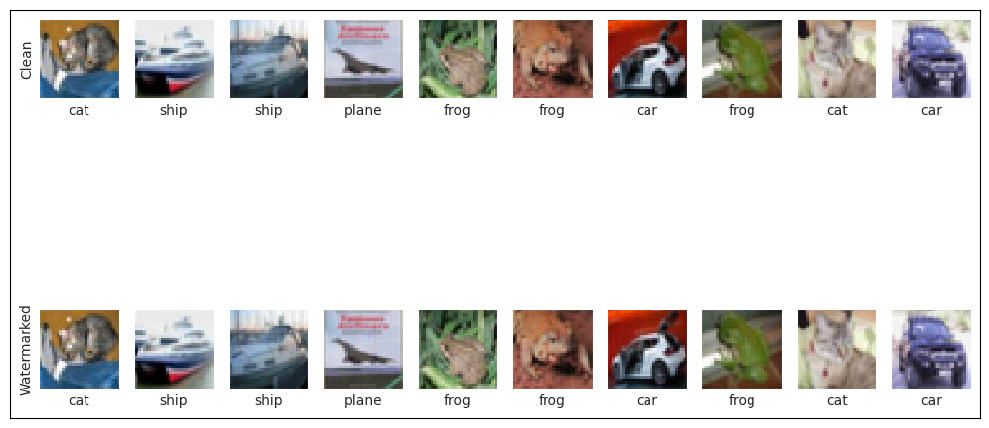

In [17]:
import matplotlib.image as mpimg

plt.figure()
img = mpimg.imread("/kaggle/input/datasets/domwhye/assignment2-images/images/acceptable_wm_2.png")
plt.imshow(img)

ax = plt.gca()
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()
plt.close()

## Implement train_watermark_model (2 marks)
Run the following cell to define the watermark decoder. Do not be confused by this watermark decoder and the decoder contained in the autoencoder:
- This watermark decoder aims to recover watermark bits, i.e., "1,0,1,0,1...".
- The decoder in the autoencoder aims to generate perturbations that will be added to clean images.

In [18]:
# this watermark decoder is a simple convolutional neural network.
class WatermarkDecoder(nn.Module):
    def __init__(self, wm_len):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(256, wm_len),
        )

    def forward(self, x):
        features = self.features(x)

        out = features.view(features.size(0), -1)
        out = self.classifier(out)

        return out

Run the following cell to create the training dataset.

In [19]:
# clean training set
clean_train_set = CIFAR10(root=str(exp_cfg.data_dir), train=True, download=True,
                            transform=transforms.Compose([
                                transforms.ToTensor(),
                                transforms.RandomHorizontalFlip(0.5),
                                transforms.Normalize(setup.CIFAR10_MEAN, setup.CIFAR10_STD)
                            ])
                         )
print(f"Size of the training set = {len(clean_train_set)}")

Size of the training set = 50000


Implement your function in the cell below. Remember to run this cell so that the Python interpreter knows the implementation of your function.

In [20]:
import torch
import torch.nn as nn
import numpy as np
# you can import other modules that help

def train_watermark_model(
        ae: nn.Module,
        decoder: nn.Module,
        wm: np.array,
        dset: torch.utils.data.Dataset,
        exp_cfg,
) -> None:
    """
    ae: an autoencoder for generating watermarks that are added to clean images.
    decoder: the model for recovering watermarks from input.
    wm: the target watermark recovered by the decoder as type np.int64.
    dset: the dataset to train on.
    exp_cfg: general configurations including out_dir, data_dir, device, etc.

    return: None.
    """

    raise NotImplementedError

Run the following cell to train models and evaluate your watermarks on the testing dataset.
You can read how the autoencoder is implemented in AutoEncoder.py.

In [21]:
from codebase.autoencoder.AutoEncoder import AutoEncoder

# the watermark to embed
wm = np.array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0], dtype=np.int64)

# the configuration for the autoencoder
encoder_cfg = [32, "M", 64, "M", 64, "M"]
decoder_cfg = ["M", 64, "M", 32, "M", 3]
in_shape = [3, 32, 32]
fc_hidden_dim = 512
latent_dim = 128

# create autoencoder and watermark decoder and train them from scratch
ae = AutoEncoder(encoder_cfg, decoder_cfg, in_shape, fc_hidden_dim, latent_dim, wm=wm)
ae = ae.to(exp_cfg.device)
decoder = WatermarkDecoder(wm.shape[0]).to(exp_cfg.device)

train_watermark_model(ae=ae, decoder=decoder, wm=wm, dset=clean_train_set, exp_cfg=exp_cfg)

ae.eval()
decoder.eval()

# use your trained autoencoder to embed watermarks into the testing data and try to decode them
clean_test_loader = torch.utils.data.DataLoader(clean_test_set, batch_size=128, num_workers=8, shuffle=False)

# plot some images for visualization
num_vis = 10
for test_x, test_y in clean_test_loader:
    test_x = test_x[:num_vis].to(exp_cfg.device)
    test_y = test_y[:num_vis]

    # add watermarks to test_x
    wm_test_x = test_x + ae(test_x)

    # concatenate them together and visualize them
    vis_x = torch.concatenate([test_x, wm_test_x], dim=0)
    test_y = torch.tile(test_y, (2,))

    vis_x = utils.unnormalize(vis_x, cifar10_mean_tensor, cifar10_std_tensor)

    utils.show_imgs_tensor(nrows=2, ncols=num_vis, imgs_arr=vis_x, labels_arr=test_y,
                            class_names=setup.CIFAR10_CLASSES,
                            ylabels=["Clean", "Watermarked"])

    break

# we consider the following metrics:
# true positive rate (TPR) = TP / (TP+FN)
# false positive rate (FPR) = FP / (FP+TN)
# true negative rate (TNR) = TN / (TN+FP)
tp_arr = []
fp_arr = []
tn_arr = []

# watermarked images should be decoded as wm
wm_tensor = torch.from_numpy(wm).long().to(exp_cfg.device)
wm_tensor = wm_tensor.unsqueeze(0)
# clean images should be decoded as all 0s
clean_wm_tensor = torch.zeros_like(wm_tensor).long()

# calculate detection metrics for all the testing images
for test_x, test_y in clean_test_loader:
    test_x = test_x.to(exp_cfg.device)

    # add watermarks to test_x
    wm_test_x = test_x + ae(test_x)

    def do_decode(_x, _target):
        decoded_x = torch.sigmoid(decoder(_x))
        decoded_x = (decoded_x > 0.5).long()

        # watermarks are identified only if all the bits are correct
        correct = (decoded_x == _target)
        correct = correct.sum(dim=1)
        correct = (correct == wm.shape[0])

        return correct

    # true positives mean watermarks are successfully recovered from watermarked images
    tp_arr.append(do_decode(wm_test_x, wm_tensor))
    # false positives mean watermarks are incorrectly recovered from clean images
    fp_arr.append(do_decode(test_x, wm_tensor))
    # true negatives mean only bits 0 are obtained from clean images result
    tn_arr.append(do_decode(test_x, clean_wm_tensor))

assert sum(x.shape[0] for x in tp_arr) == len(clean_test_set), "All the testing data must be included."

tpr = torch.concatenate(tp_arr, dim=0).cpu().detach().numpy().mean()
fpr = torch.concatenate(fp_arr, dim=0).cpu().detach().numpy().mean()
tnr = torch.concatenate(tn_arr, dim=0).cpu().detach().numpy().mean()

print(f"TPR = {tpr*100.0:.1f}%, FPR = {fpr*100.0:.1f}%, TNR = {tnr*100.0:.1f}%")

# calculate marks
task4_marks = 0
if fpr >= 0.05:
    print(f"Your FPR is too large")
else:
    if (tpr >= 0.95) and (tnr >= 0.95):
        task4_marks = 2
    else:
        task4_marks = 0

print(f"\n******* Your marks for Optional Task coding part is {task4_marks}/2. *******\n")

NotImplementedError: 

## Briefly describe how you implement the watermarks. (1 mark)

Your answer:

# Submission

After running all cells in this notebook, click "File -> Download Notebook" to save this notebook as "assignment2-csit375.ipynb" locally.
Please open this file with Kaggle or another Python notebook editor (e.g., Colab) again to confirm that all the results are correctly shown.

For submission, you only need to submit **assignment2-csit375.ipynb**.

Zip it into a single **zip** file (do NOT use .rar). Submit this zip file via Moodle by the due date and time. Assignments that are not submitted on Moodle will not be marked.